In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Airbnb_Open_Data.csv")

C:\Users\dgarc150\AppData\Local\Temp\ipykernel_26760\4187945493.py:7: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Airbnb_Open_Data.csv")


In [2]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [3]:
df.dtypes

id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

In [4]:
df_before = df.copy()

df = df.drop(columns=['host id', 'id', 'country', 'country code'])

df.head()

,NAME,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,Clean & quiet apt home by the park,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,Skylit Midtown Castle,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,THE VILLAGE OF HARLEM....NEW YORK !,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,NaN,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,True,moderate,Entire home/apt,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,Entire Apt: Spacious Studio/Loft by central park,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,Entire home/apt,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [5]:
df.isnull().sum().sort_values()

room type                              0
long                                   8
lat                                    8
neighbourhood                         16
neighbourhood group                   29
cancellation_policy                   76
instant_bookable                     105
number of reviews                    183
Construction year                    214
price                                247
NAME                                 250
service fee                          273
host_identity_verified               289
calculated host listings count       319
review rate number                   326
host name                            406
minimum nights                       409
availability 365                     448
reviews per month                  15879
last review                        15893
house_rules                        52131
license                           102597
dtype: int64

In [6]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [8]:
cat_cols = df.select_dtypes(include=['object']).columns

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [9]:
df.duplicated().sum()

np.int64(3461)

In [10]:
rows_before = df.shape[0]

df = df.drop_duplicates()

rows_after = df.shape[0]

In [11]:
print("Records before removing duplicates: ", rows_before)
print("Records after removing duplicates: ",rows_after)

Records before removing duplicates:  102599
Records after removing duplicates:  99138


In [ ]:
# Renaming the column 'availability 365' to 'days_booked'
df = df.rename(columns={'availability 365':'days_booked'})

In [ ]:
# Converting all column names to lowercase and replacing spaces with underscore (_)
df.columns = df.columns.str.lower().str.replace(' ','_')

In [16]:
# Removing the dollar sign ($) and comma (,) from the columns price and service_fee. 
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)
df['service_fee'] = df['service_fee'].replace(r'[\$,]', '', regex=True).astype(float)

In [17]:
# Showing the count of various room types available in the dataset.
df['room_type'].value_counts()

room_type
Entire home/apt    51987
Private room       44887
Shared room         2149
Hotel room           115
Name: count, dtype: int64

In [19]:
df.groupby('room_type')['cancellation_policy'].value_counts()

room_type        cancellation_policy
Entire home/apt  moderate               17389
                 flexible               17360
                 strict                 17238
Hotel room       flexible                  44
                 moderate                  37
                 strict                    34
Private room     moderate               15121
                 strict                 14936
                 flexible               14830
Shared room      strict                   718
                 moderate                 717
                 flexible                 714
Name: count, dtype: int64

In [20]:
# Showing the average price per neighborhood group
avg_price = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
avg_price

neighbourhood_group
Queens           628.668822
Brooklyn         625.471627
Bronx            625.271511
Staten Island    625.060870
Manhattan        621.666140
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64

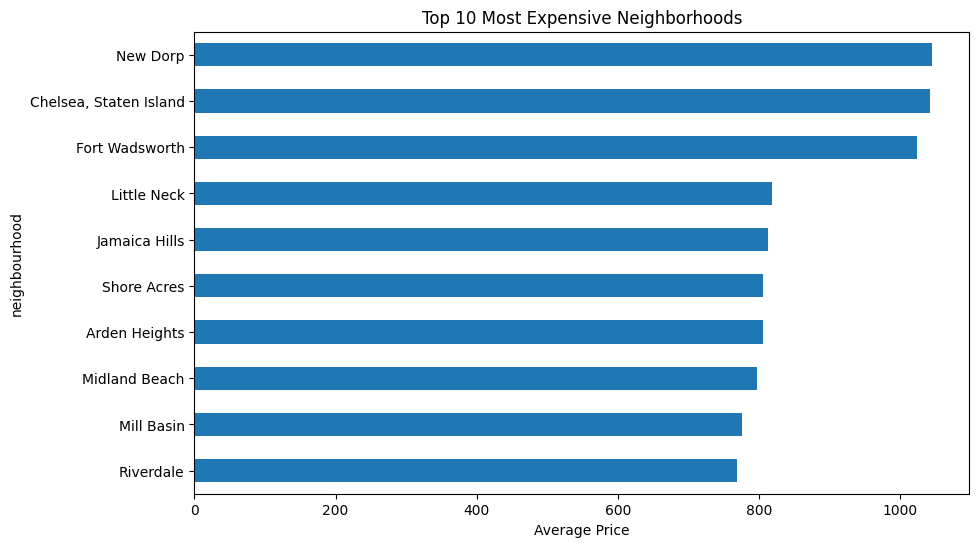

In [21]:
# Top 10 expensive neighborhoods

top10 = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)
 
plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Most Expensive Neighborhoods")
plt.xlabel("Average Price")
plt.show()

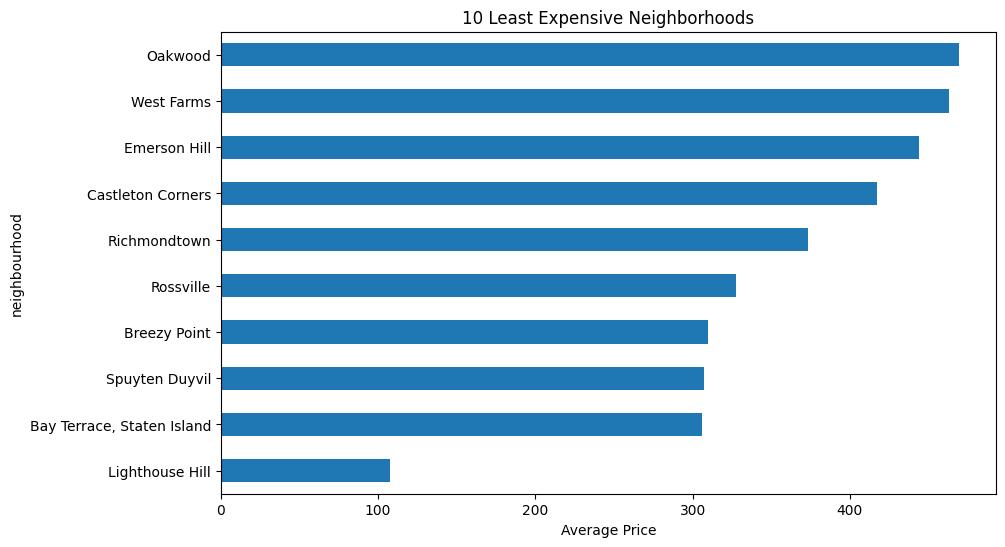

In [22]:
# Cheapest neighborhoods
cheap10 = df.groupby('neighbourhood')['price'].mean().sort_values().head(10)
 
plt.figure(figsize=(10,6))
cheap10.plot(kind='barh')
plt.title("10 Least Expensive Neighborhoods")
plt.xlabel("Average Price")
plt.show()

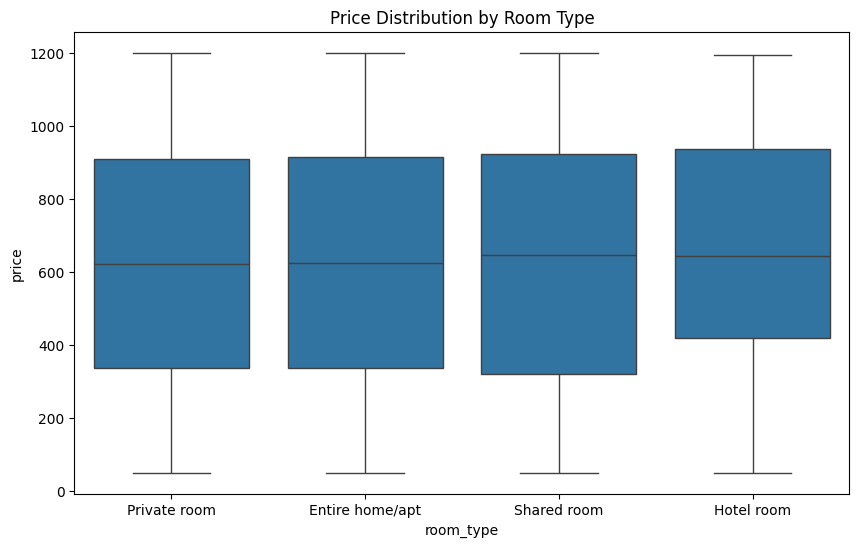

In [23]:
# Boxplot price by room type
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='room_type', y='price')
plt.title("Price Distribution by Room Type")
plt.show()

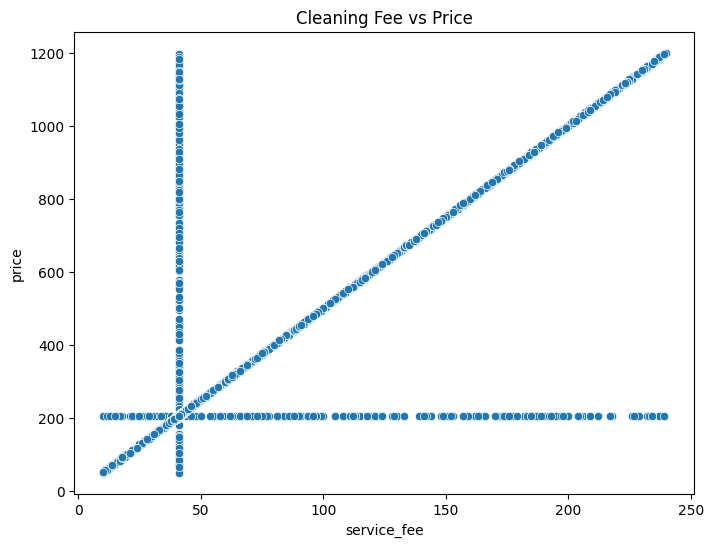

In [26]:
# Scatter plot cleaning fee vs Price
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='service_fee', y='price')
plt.title("Cleaning Fee vs Price")
plt.show()

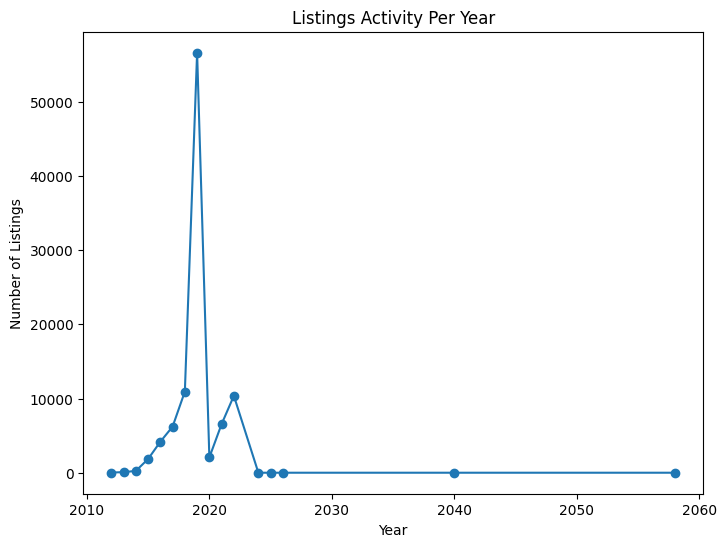

In [27]:
# Line Charts - Listings per year
df['last_review'] = pd.to_datetime(df['last_review'])
 
listings_year = df['last_review'].dt.year.value_counts().sort_index()
 
plt.figure(figsize=(8,6))
listings_year.plot(kind='line', marker='o')
plt.title("Listings Activity Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Listings")
plt.show()

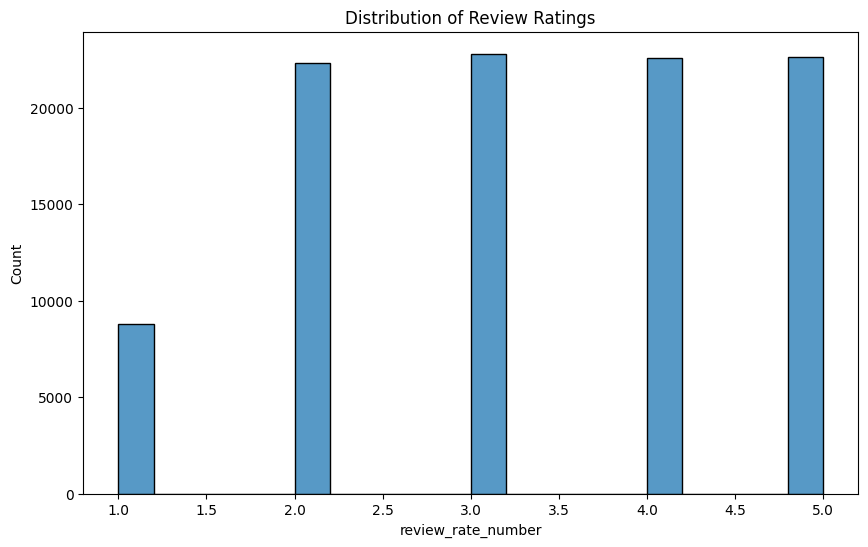

In [28]:
# Visualization using review scores
plt.figure(figsize=(10,6))
sns.histplot(df['review_rate_number'], bins=20)
plt.title("Distribution of Review Ratings")
plt.show()

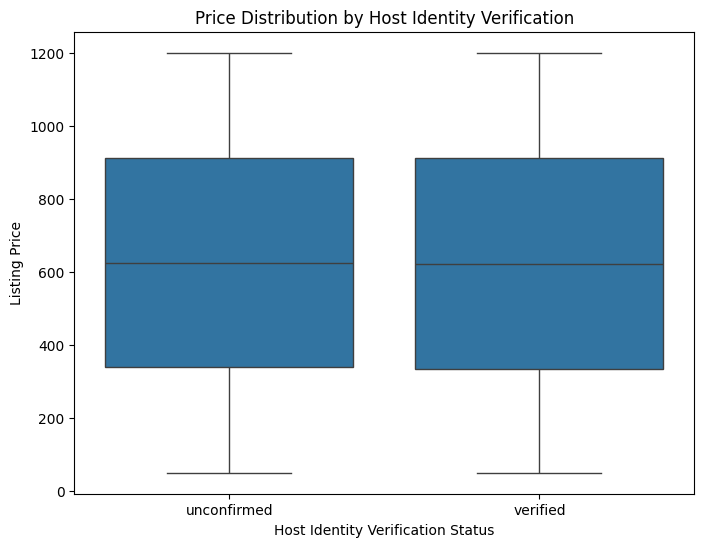

In [30]:
# Comparing Superhosts vs Regular hosts
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='host_identity_verified', y='price')
 
plt.title("Price Distribution by Host Identity Verification")
plt.xlabel("Host Identity Verification Status")
plt.ylabel("Listing Price")
 
plt.show()